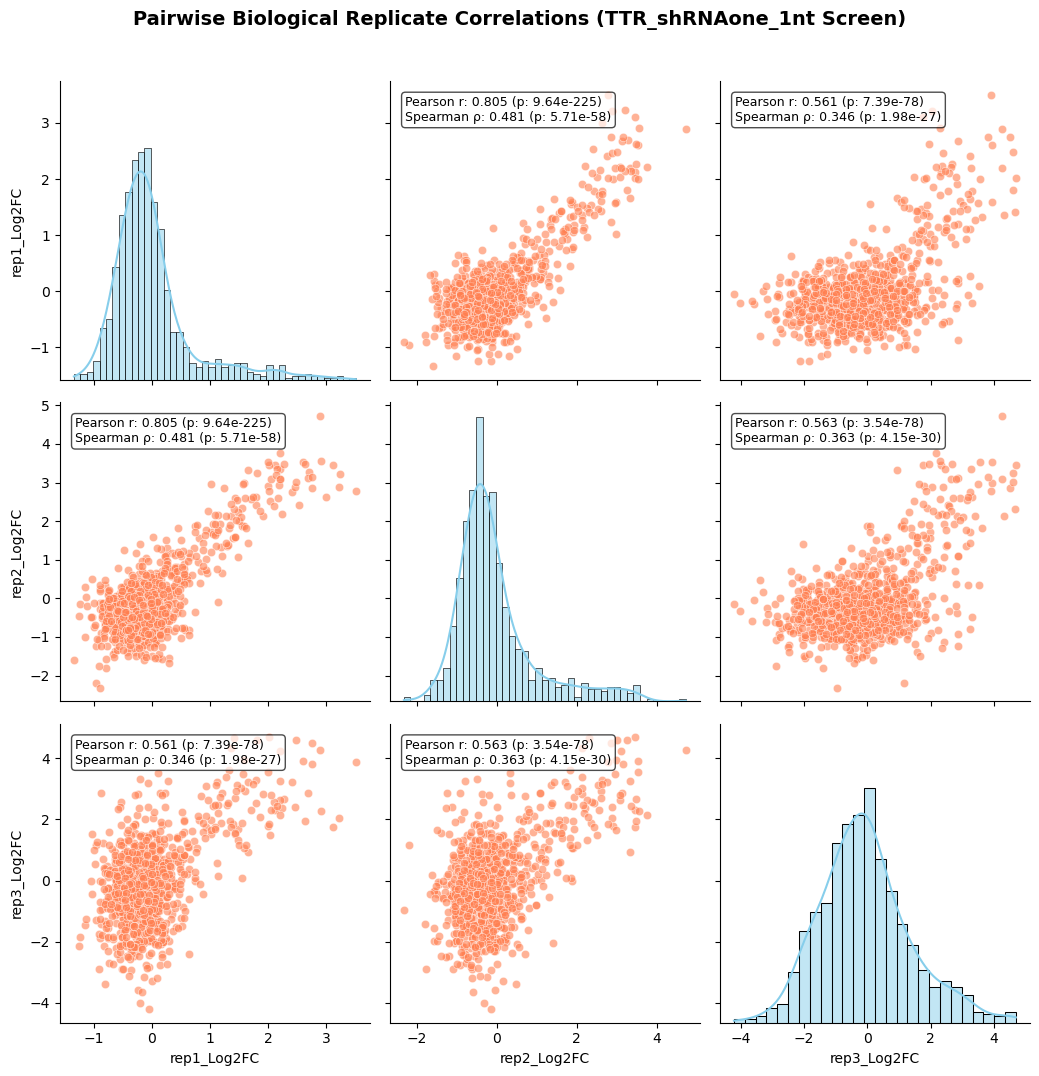

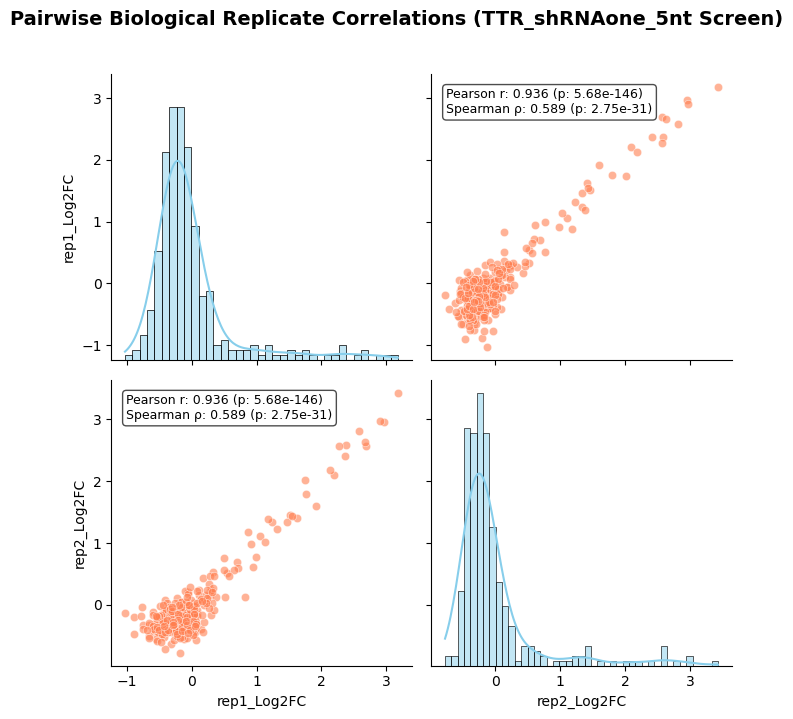

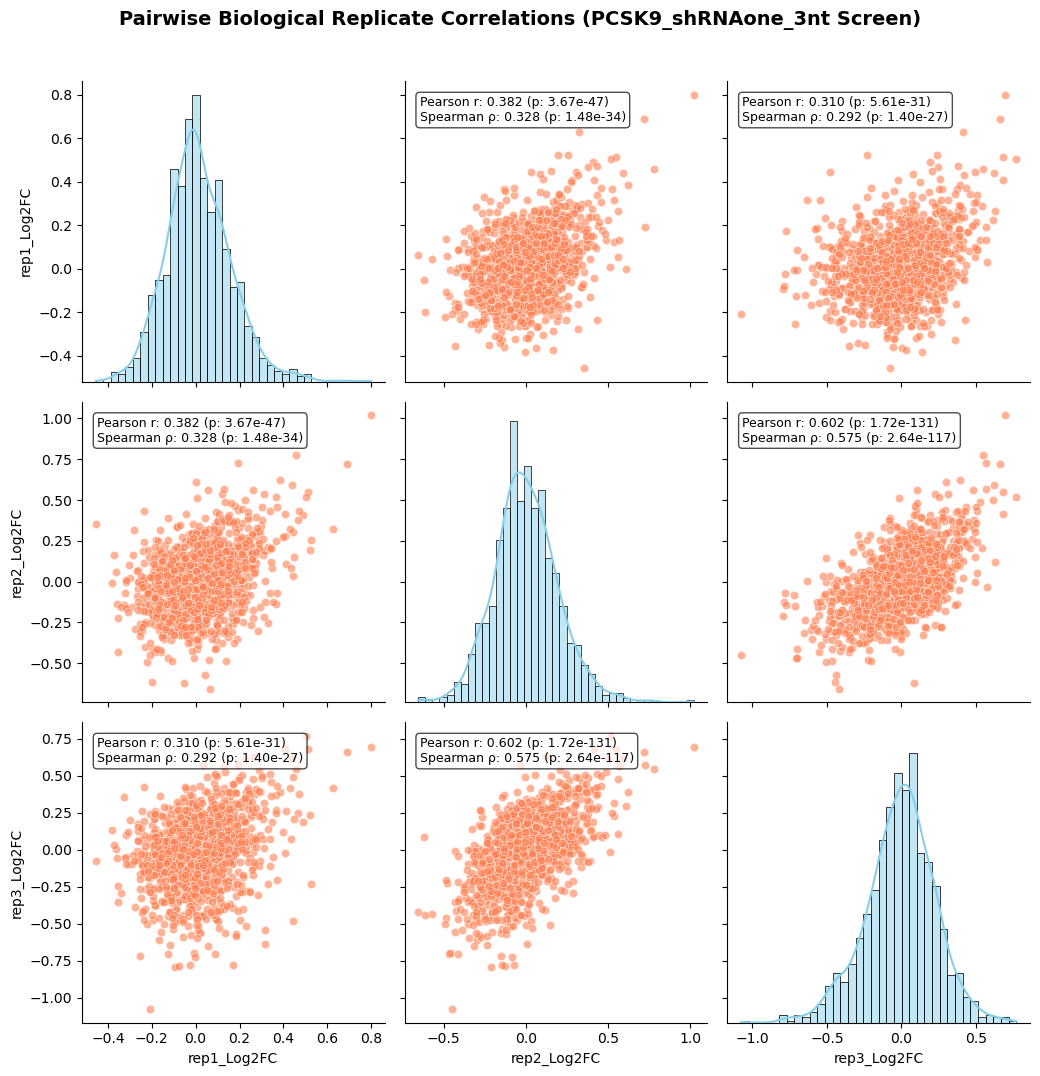

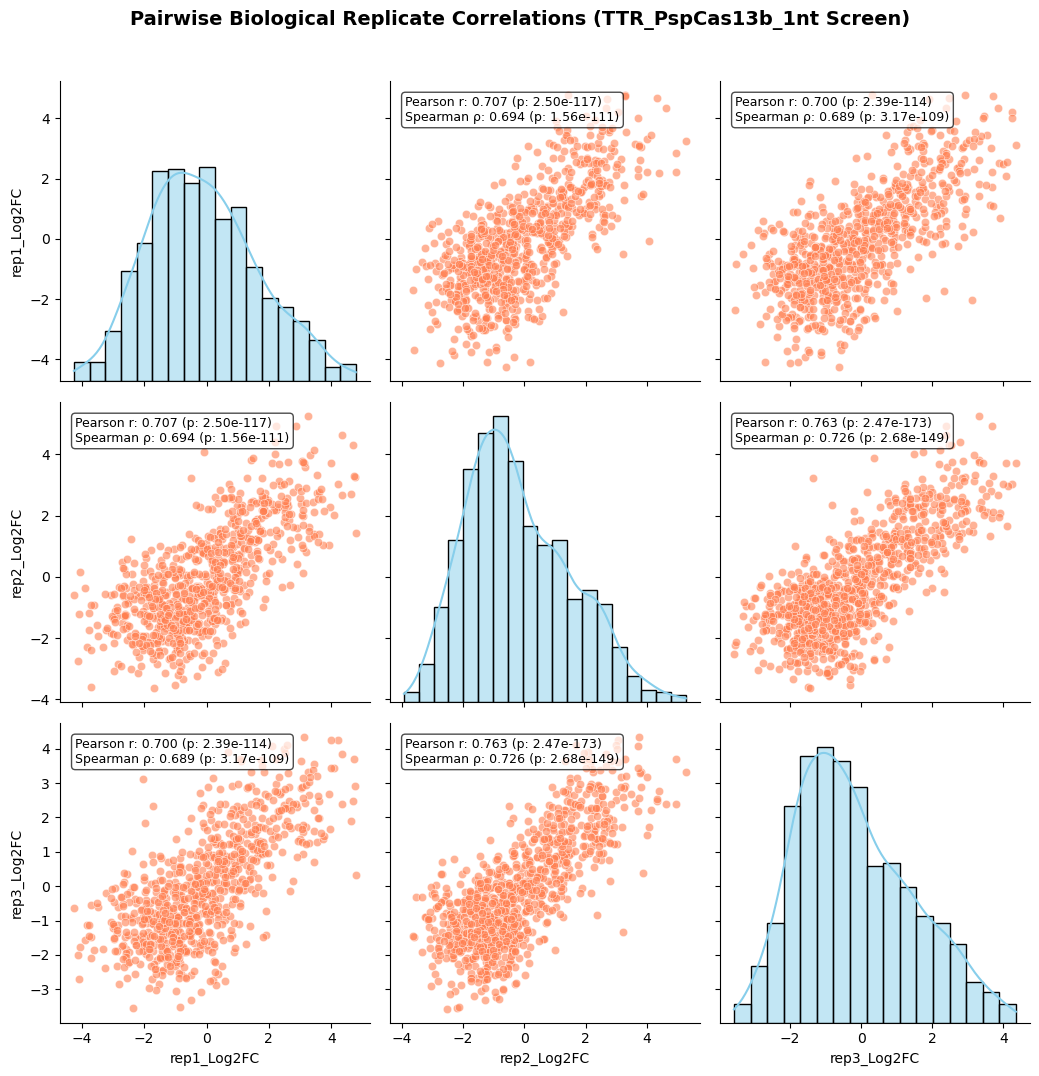

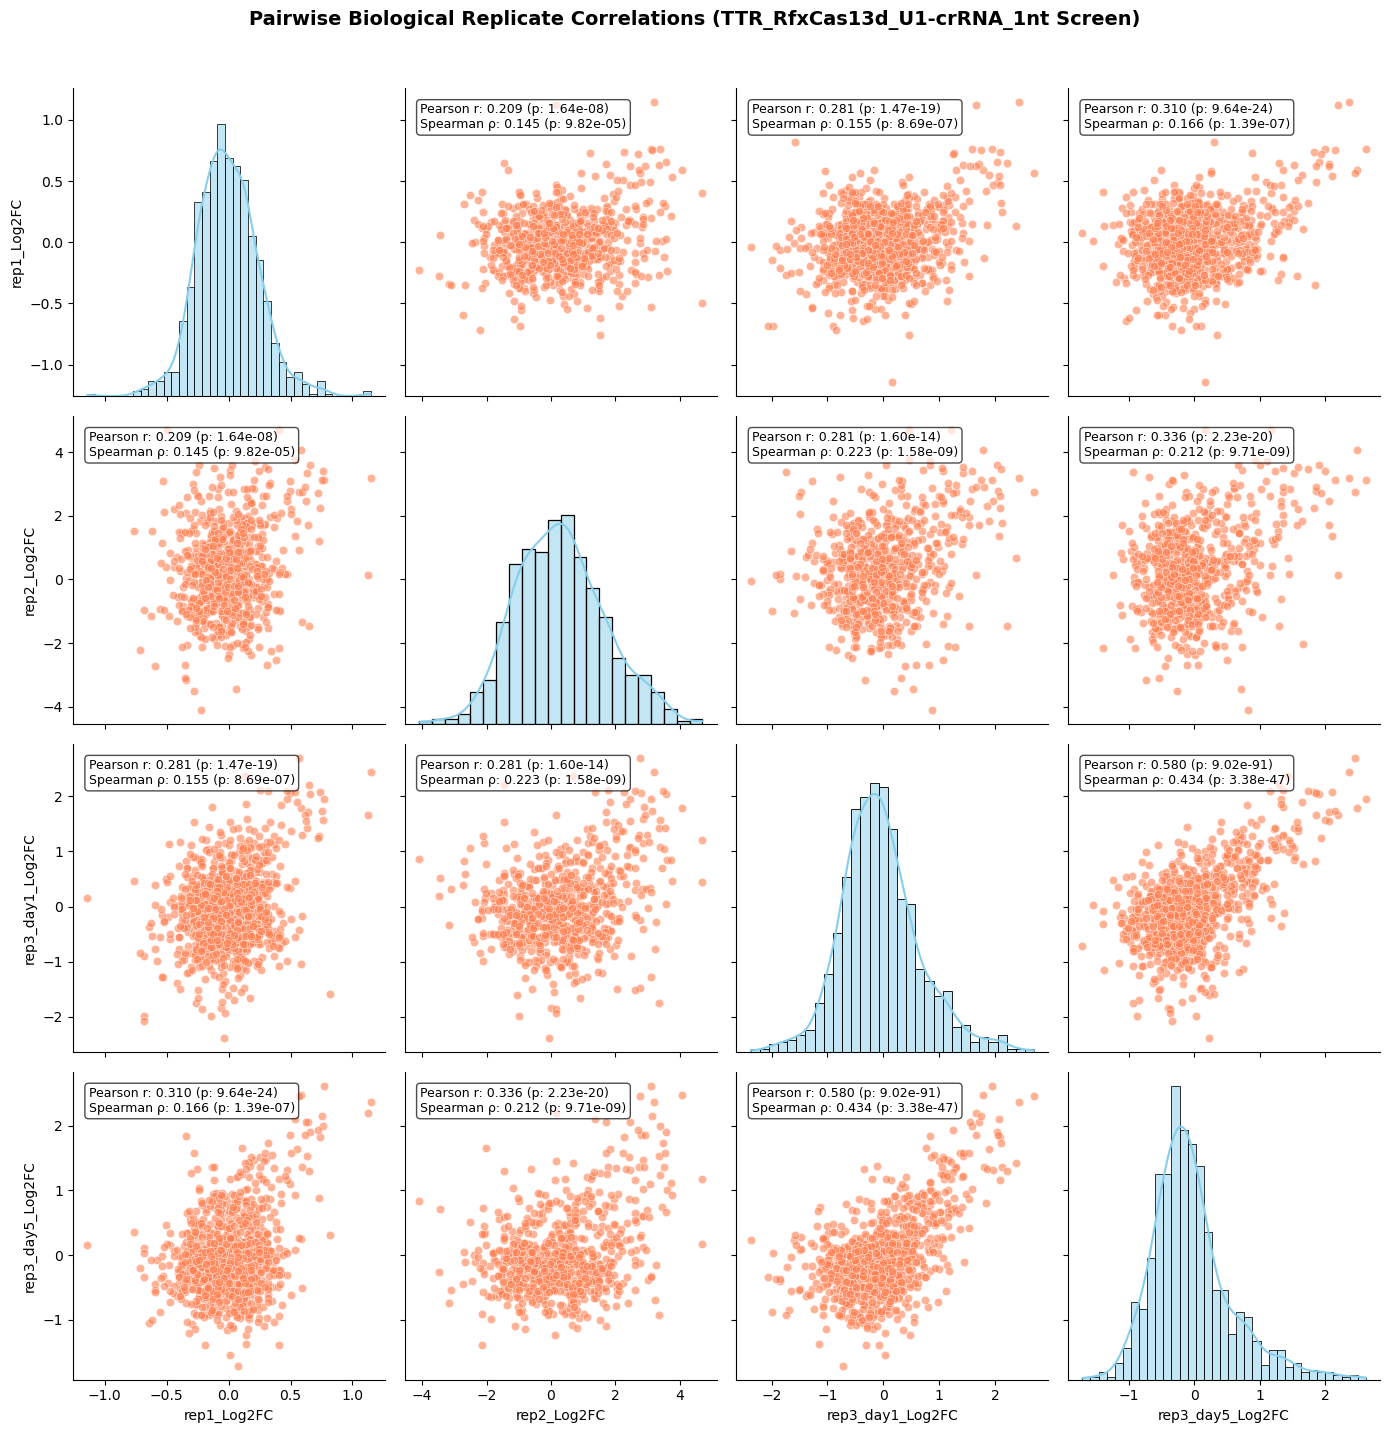

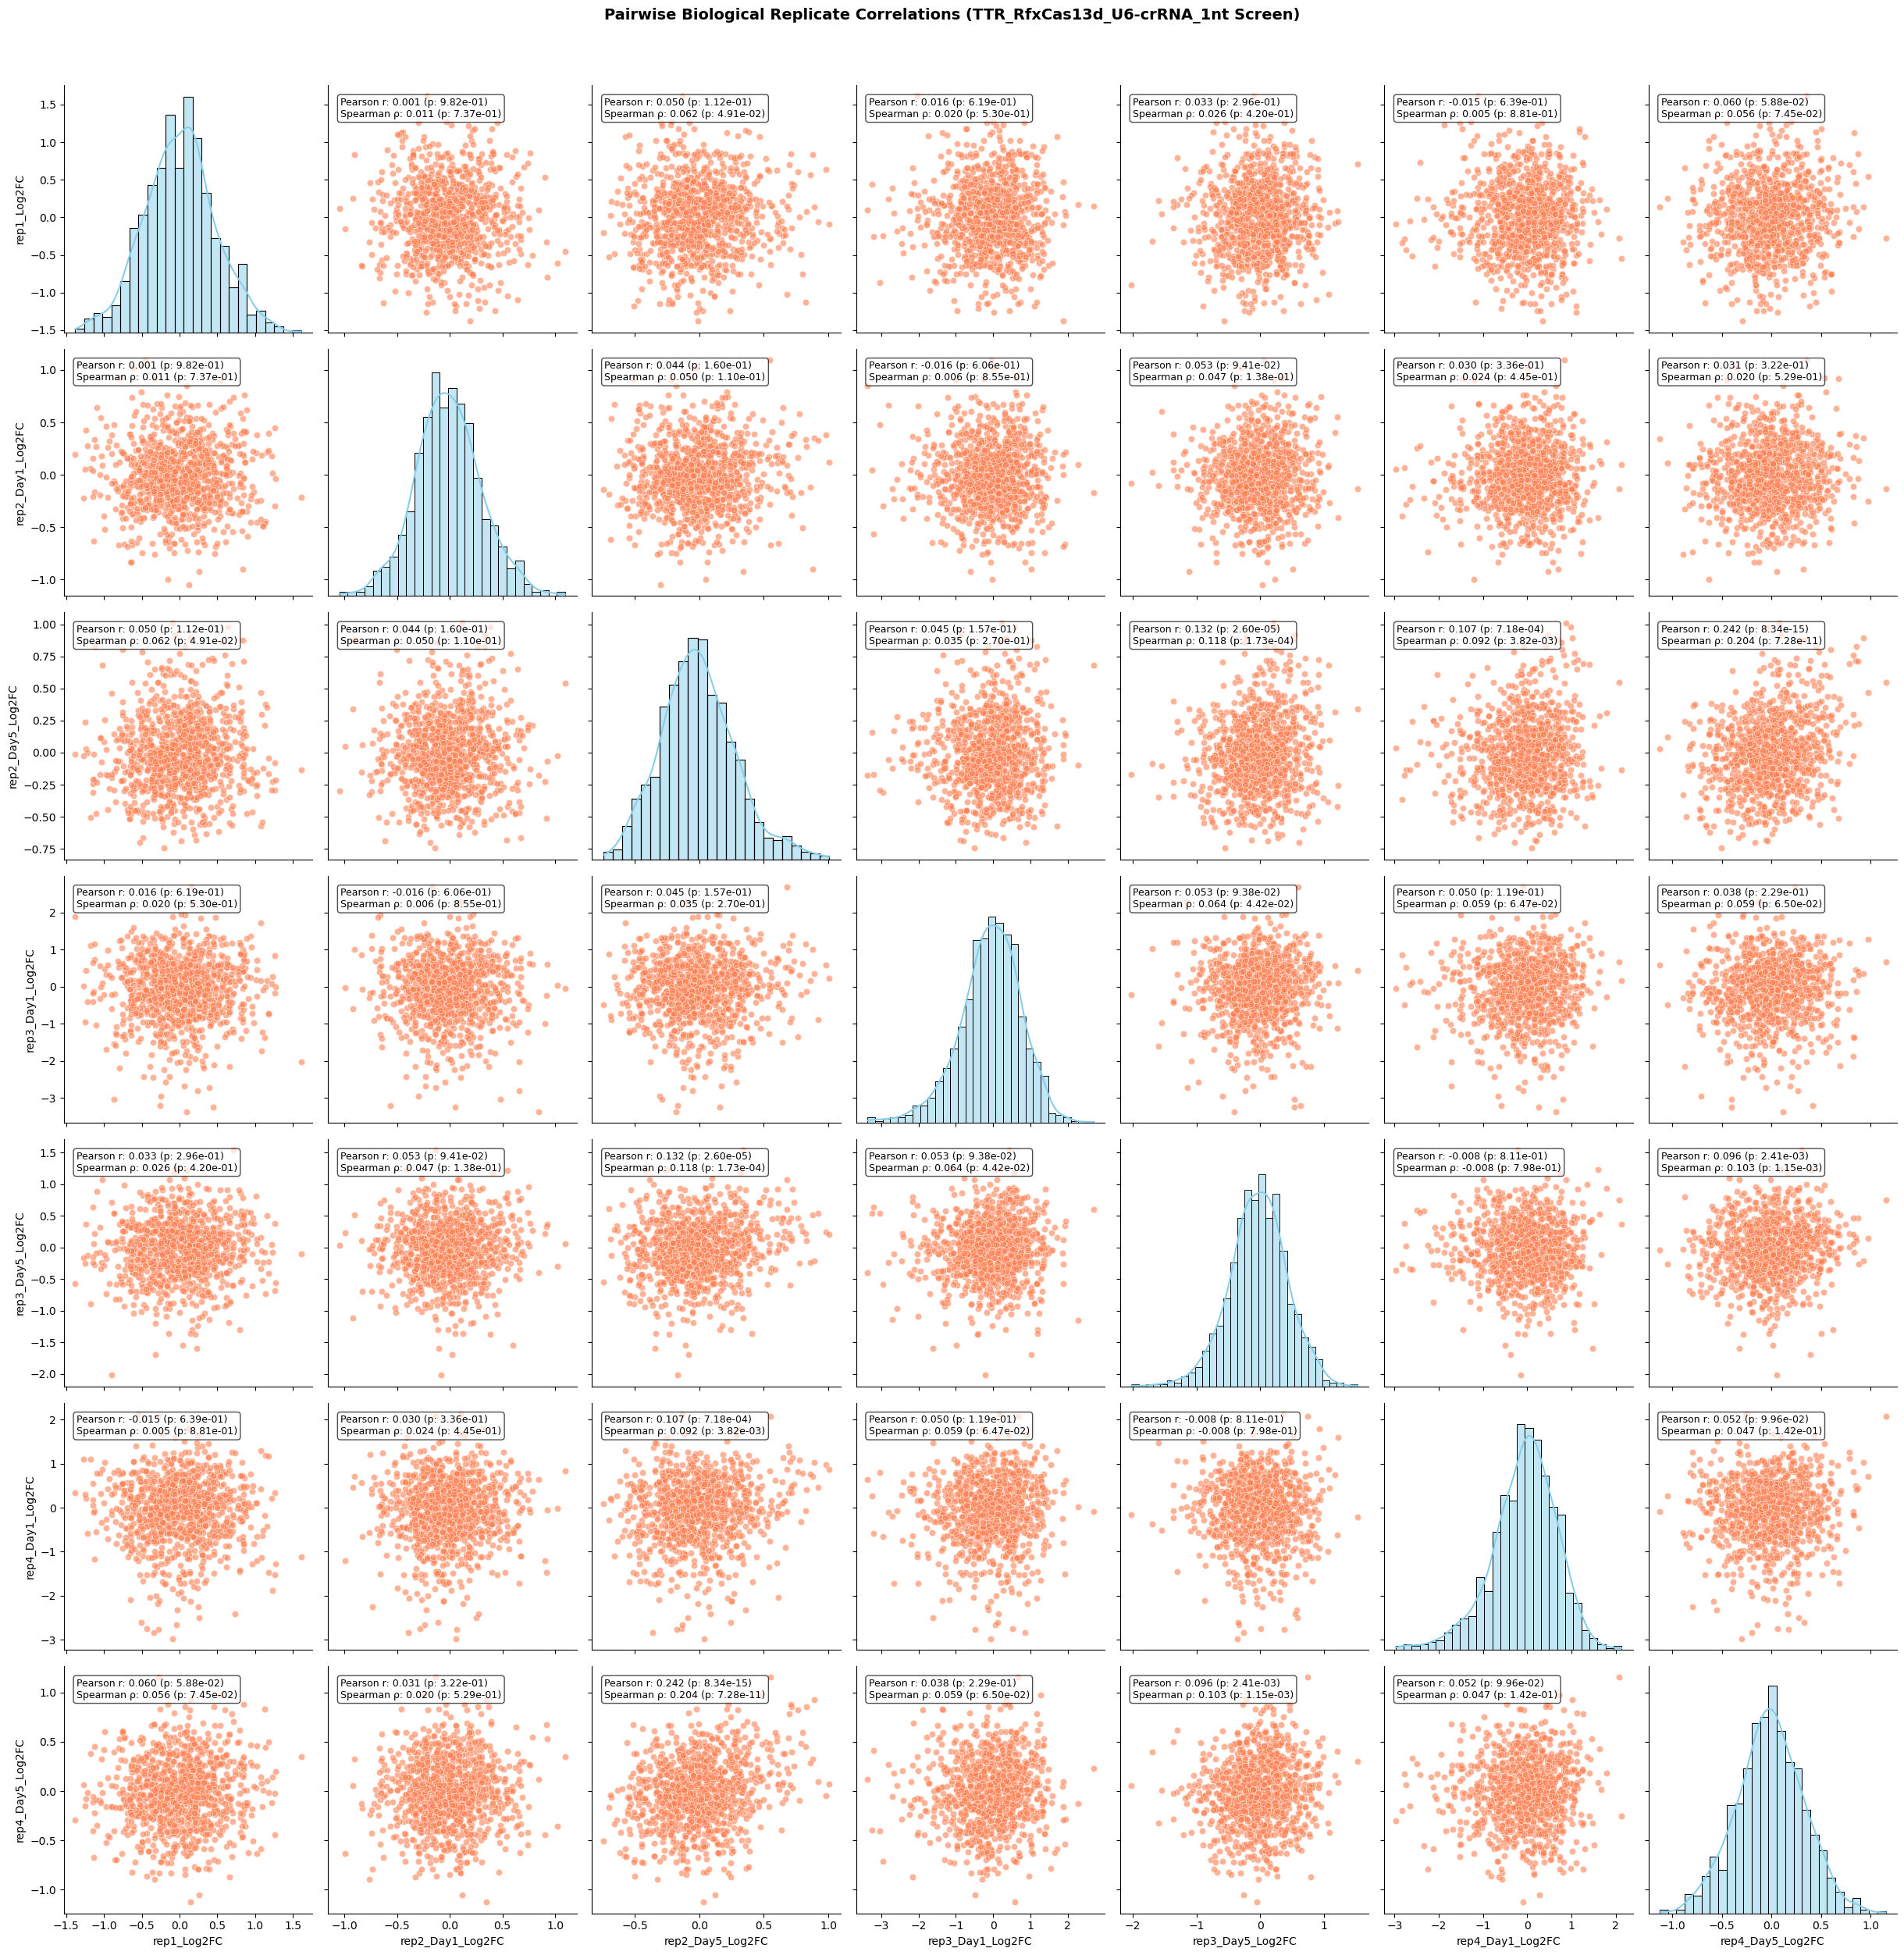

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


screen = ["TTR_shRNAone_1nt", "TTR_shRNAone_5nt", "PCSK9_shRNAone_3nt", "TTR_PspCas13b_1nt", "TTR_RfxCas13d_U1-crRNA_1nt", "TTR_RfxCas13d_U6-crRNA_1nt"]
dataDir = ["/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_1nt.csv",
           "/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_5nt.csv",
           "/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_PCSK9_shRNAone_3nt.csv",
           "/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_PspCas13b_1nt.csv",
           "/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv",
           "/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_RfxCas13d_U6-crRNA_1nt.csv"]

for screen, data in zip(screen, dataDir):
    df_screen = pd.read_csv(data)
    columns = [x for x in df_screen.columns.tolist() if x.endswith("Log2FC")]
    df_screen = df_screen[columns]
    df_screen

    #######################################################################################################################
    #######################################################################################################################
    #######################################################################################################################
    def annotate_stats(x, y, **kwargs):
        # Drop NaNs dynamically for calculating correlations if any rows are missing data
        mask = x.notna() & y.notna()
        x_clean, y_clean = x[mask], y[mask]

        if len(x_clean) < 2:
            return  # Not enough data points to compute correlation

        # Calculate Pearson and Spearman stats
        p_coef, p_val = pearsonr(x_clean, y_clean)
        s_coef, s_val = spearmanr(x_clean, y_clean)

        # Format text labels (scientific notation for p-values is safest for small numbers)
        stats_text = (
            f"Pearson r: {p_coef:.3f} (p: {p_val:.2e})\n"
            f"Spearman ρ: {s_coef:.3f} (p: {s_val:.2e})"
        )

        # Grab current axes object
        ax = plt.gca()

        # Place text box in the upper-left or lower-right corner depending on preference
        ax.text(
            0.05,
            0.95,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            horizontalalignment="left",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
        )


    # 3. Initialize the PairGrid object
    # We use 'vars' to strictly limit the plotting to your 3 target replicate columns
    g = sns.PairGrid(df_screen, vars=columns, height=3.5)

    # 4. Map plots to the Grid
    # Diagonal: Distribution histograms
    g.map_diag(sns.histplot, kde=True, color="skyblue")

    # Off-diagonal (upper and lower triangles): Scatter plots
    g.map_offdiag(sns.scatterplot, alpha=0.6, color="coral", edgecolor="w")

    # 5. Map the annotation function to the off-diagonal plots
    g.map_offdiag(annotate_stats)

    # 6. Aesthetic adjustment & show
    plt.suptitle(
        "Pairwise Biological Replicate Correlations (" + screen + " Screen)",
        y=1.02,
        fontsize=14,
        weight="bold",
    )
    plt.tight_layout()
    plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_" + screen + ".pdf", bbox_inches="tight")
    plt.show()

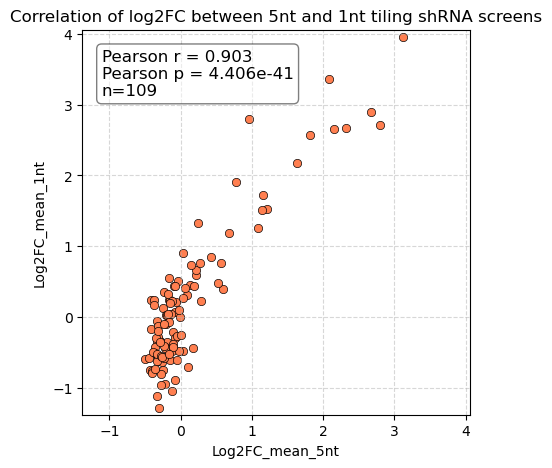

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats


df_TTR_shRNAone_1nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv")
df_TTR_shRNAone_1nt = df_TTR_shRNAone_1nt[["target_seq", "Log2FC_mean"]].rename(columns={"Log2FC_mean": "Log2FC_mean_1nt"})
df_TTR_shRNAone_5nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_5nt.csv")
name_list = df_TTR_shRNAone_5nt[df_TTR_shRNAone_5nt["tech_rep"] == "U_starting"]["name"].to_list()
Ulog2FC = df_TTR_shRNAone_5nt[df_TTR_shRNAone_5nt["tech_rep"] == "U_starting"]["Log2FC_mean"].to_list()
Alog2FC = df_TTR_shRNAone_5nt[df_TTR_shRNAone_5nt["tech_rep"] == "A_starting"]["Log2FC_mean"].to_list()
df_TTR_shRNAone_5nt = pd.DataFrame({"name": name_list, "Log2FC_mean_5nt": [(a + b) / 2 for a, b in zip(Ulog2FC, Alog2FC)], "target_seq": df_TTR_shRNAone_5nt[df_TTR_shRNAone_5nt["tech_rep"] == "U_starting"]["target_seq"].to_list()})

df = pd.merge(df_TTR_shRNAone_5nt, df_TTR_shRNAone_1nt, how = 'left', on = "target_seq").dropna()

PearsonR, PearsonP = pearsonr(df['Log2FC_mean_5nt'], df['Log2FC_mean_1nt'])
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)
min_val = min(df['Log2FC_mean_5nt'].min(), df['Log2FC_mean_1nt'].min()) - 0.1
max_val = max(df['Log2FC_mean_5nt'].max(), df['Log2FC_mean_1nt'].max()) + 0.1
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
sns.scatterplot(data=df, x='Log2FC_mean_5nt', y='Log2FC_mean_1nt', color = 'coral', edgecolors = '#000000')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Correlation of log2FC between 5nt and 1nt tiling shRNA screens')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_TTR_shRNAone_5nt_vs_1nt.pdf", bbox_inches='tight')
plt.show()
plt.close()


[613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258, 568]
                        name          target_seq    tech_rep  \
150  shRNAone-TTR_1A|483-500  CAGCCAACGACTCCGGCC  A_starting   
133  shRNAone-TTR_1A|568-585  TCCCAAGGAATGAGGGAC  A_starting   
23   shRNAone-TTR_1U|568-585  TCCCAAGGAATGAGGGAC  U_starting   
35   shRNAone-TTR_1U|508-525  CTACACCATTGCCGCCCT  U_starting   
40   shRNAone-TTR_1U|483-500  CAGCCAACGACTCCGGCC  U_starting   
163  shRNAone-TTR_1A|418-435  CACCAAATCTTACTGGAA  A_starting   
145  shRNAone-TTR_1A|508-525  CTACACCATTGCCGCCCT  A_starting   
154  shRNAone-TTR_1A|463-480  GCATGCAGAGGTGGTATT  A_starting   
44   shRNAone-TTR_1U|463-480  GCATGCAGAGGTGGTATT  U_starting   
153  shRNAone-TTR_1A|468-485  CAGAGGTGGTATTCACAG  A_starting   
53   shRNAone-TTR_1U|418-435  CACCAAATCTTACTGGAA  U_starting   
43   shRNAone-TTR_1U|468-485  CAGAGGTGGTATTCACAG  U_starting   
113  shRNAone-TTR_1A|668-685  ACCTCATATGCTATGTTA  A_starting   
3    shRNAone-TTR_

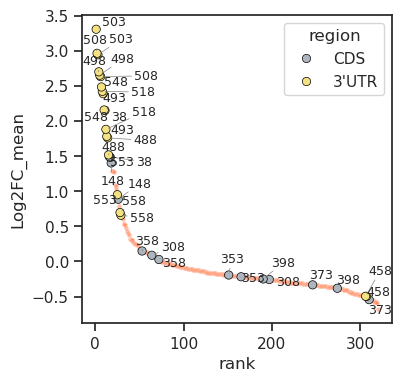

[613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258, 568]
                     name          target_seq  start_nt_NM_000371.3  \
567  shRNAone-TTR|568-585  TCCCAAGGAATGAGGGAC                   568   
482  shRNAone-TTR|483-500  CAGCCAACGACTCCGGCC                   483   
507  shRNAone-TTR|508-525  CTACACCATTGCCGCCCT                   508   
462  shRNAone-TTR|463-480  GCATGCAGAGGTGGTATT                   463   
467  shRNAone-TTR|468-485  CAGAGGTGGTATTCACAG                   468   
417  shRNAone-TTR|418-435  CACCAAATCTTACTGGAA                   418   
667  shRNAone-TTR|668-685  ACCTCATATGCTATGTTA                   668   
257  shRNAone-TTR|258-275  GAGGCAGTCCTGCCATCA                   258   
662  shRNAone-TTR|663-680  TTTTCACCTCATATGCTA                   663   
597  shRNAone-TTR|598-615  GGACCTGAAGGACGAGGG                   598   
147  shRNAone-TTR|148-165  TCGTCTGCTCCTCCTCTG                   148   
627  shRNAone-TTR|628-645  GTAACCAAGAGTATTCCA                 

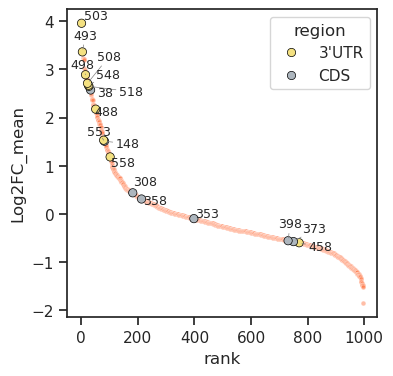

[]


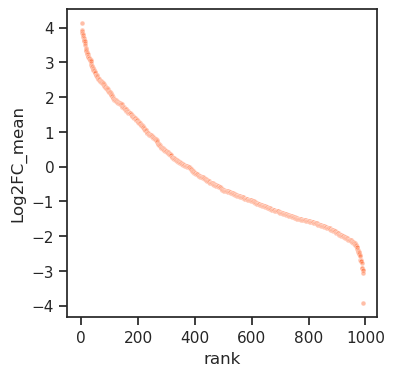

[3335, 3395, 3638, 704, 2684, 3077, 425, 3590, 3035, 2783, 2774, 911, 3176, 260, 1688, 1067, 1580, 224, 3605]
                          name          target_seq  start_nt_NM_174936.3  \
1057  shRNAone-PCSK9|3176-3193  CACTACCCGGCAGGGTAC                  3176   
74      shRNAone-PCSK9|224-241  GCGCCCCTTCACGCGCCC                   224   
561   shRNAone-PCSK9|1688-1705  CGCCCTGCCCCCCAGCAC                  1688   
354   shRNAone-PCSK9|1067-1084  CGGCCGGGATGCCGGCGT                  1067   
525   shRNAone-PCSK9|1580-1597  CACCCTGGCCGAGTTGAG                  1580   
86      shRNAone-PCSK9|260-277  CCTGCACAGTCCTCCCCA                   260   
1010  shRNAone-PCSK9|3035-3052  GCCTTGGTTTCCTGAGCC                  3035   
1200  shRNAone-PCSK9|3605-3622  AGACCTGTTTTGCTTTTG                  3605   
302     shRNAone-PCSK9|911-928  TCTCCTAGACACCAGCAT                   911   
233     shRNAone-PCSK9|704-721  CTTCCATGGCCTTCTTCC                   704   
140     shRNAone-PCSK9|425-442  GCTCCTGGGTCCCGCGGG    

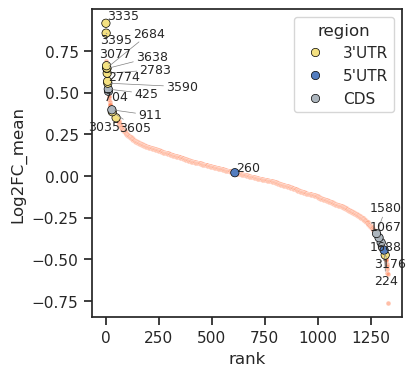

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from adjustText import adjust_text

df_TTR_shRNAone_5nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_5nt.csv")
df_TTR_shRNAone_1nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv")
df_TTR_PspCas13b_1nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_PspCas13b_1nt.csv")
df_PCSK9_shRNAone_3nt = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_PCSK9_shRNAone_3nt.csv")
gene = ["TTR_shRNAone_5nt", "TTR_shRNAone_1nt", "TTR_PspCas13b_1nt", "PCSK9_shRNAone_3nt"]

validated = [
    [613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258, 568],
    [613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258, 568],
    [],
    [3335, 3395, 3638, 704, 2684, 3077, 425, 3590, 3035, 2783, 2774, 911, 3176, 260, 1688, 1067, 1580, 224, 3605]
]
for transcript, df_gene, valid in zip(gene, [df_TTR_shRNAone_5nt, df_TTR_shRNAone_1nt, df_TTR_PspCas13b_1nt, df_PCSK9_shRNAone_3nt], validated):
    print(valid)
    df_gene = df_gene.sort_values(by=['Log2FC_mean'], ascending=False)
    df_gene["rank"] = [i + 1 for i in range(len(df_gene))]
    plt.figure(figsize=(4, 4))
    sns.set_theme(style="ticks")
    sns.scatterplot(
        data=df_gene, 
        x="rank", 
        y="Log2FC_mean", 
        s = 12, 
        color="coral", 
        alpha=0.5, 
        edgecolor="#ffffff", 
        linewidth = 0.4
        )
    
    custom_palette = {
        "Misannotated": "#bd262a",
        "5'UTR": "#537dbf",
        "CDS": "#adb6be",
        "3'UTR": "#f4e181",
    }

    if transcript == "TTR_shRNAone_5nt" or transcript == "TTR_shRNAone_1nt":
        df_gene = df_gene[~(df_gene["region"] == "NTC")].astype({"start_nt_NM_000371.3": int})
        df_valid = df_gene[df_gene["start_nt_NM_000371.3"].isin(valid)].sort_values(by=['Log2FC_mean'], ascending=True)
        print(df_valid)
        sns.scatterplot(
            data=df_valid,
            x="rank",
            y="Log2FC_mean",
            hue="region",
            palette=custom_palette,
            s=36,
            edgecolor="black",
            linewidth=0.5,
        )
        texts = []
        for index, row in df_valid.iterrows():
            texts.append(
                plt.text(
                    row["rank"],
                    row["Log2FC_mean"],
                    row["start_nt_NM_000371.4"],  # <-- Your label column
                    size=9,
                )
            )
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    elif transcript == "PCSK9_shRNAone_3nt":
        df_gene = df_gene[~(df_gene["region"] == "NTC")].astype({"start_nt_NM_174936.3": int})
        df_valid = df_gene[df_gene["start_nt_NM_174936.3"].isin(valid)].sort_values(by=['Log2FC_mean'], ascending=True)
        print(df_valid)
        sns.scatterplot(
            data=df_valid,
            x="rank",
            y="Log2FC_mean",
            hue="region",
            palette=custom_palette,
            s=36,
            edgecolor="black",
            linewidth=0.5,
        )
        texts = []
        for index, row in df_valid.iterrows():
            texts.append(
                plt.text(
                    row["rank"],
                    row["Log2FC_mean"],
                    row["start_nt_NM_174936.3"],  # <-- Your label column
                    size=9,
                )
            )
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    

    plt.savefig(f"/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/{transcript}_ranked_scatter.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # region_matrix = pd.crosstab(df_gene["region"], df_gene["rank"])
    # region_order = ["5'UTR", "CDS", "3'UTR", "Misannotated", "NTC"]

    # data_list = []
    # for type in region_order:
    #     data_list.append([1 if region == type else 0 for region in df_gene["region"]])    

    # for l in data_list:
    #     print(l.count(1))
    # plt.figure(figsize=(16, 2))

    # custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [(0.0, "#ffffff"),(1.0, "#bd262a")])

    # sns.heatmap(
    # data=data_list,
    # cmap = custom_cmap,
    # yticklabels = region_order,
    # rasterized=False
    # )
    # plt.title("Heatmap from List of Lists", fontsize=14, pad=10)
    # plt.tight_layout()
    # plt.savefig(f"/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/{transcript}_heatmap_region.pdf", dpi=300, bbox_inches='tight')
    # plt.show()

    

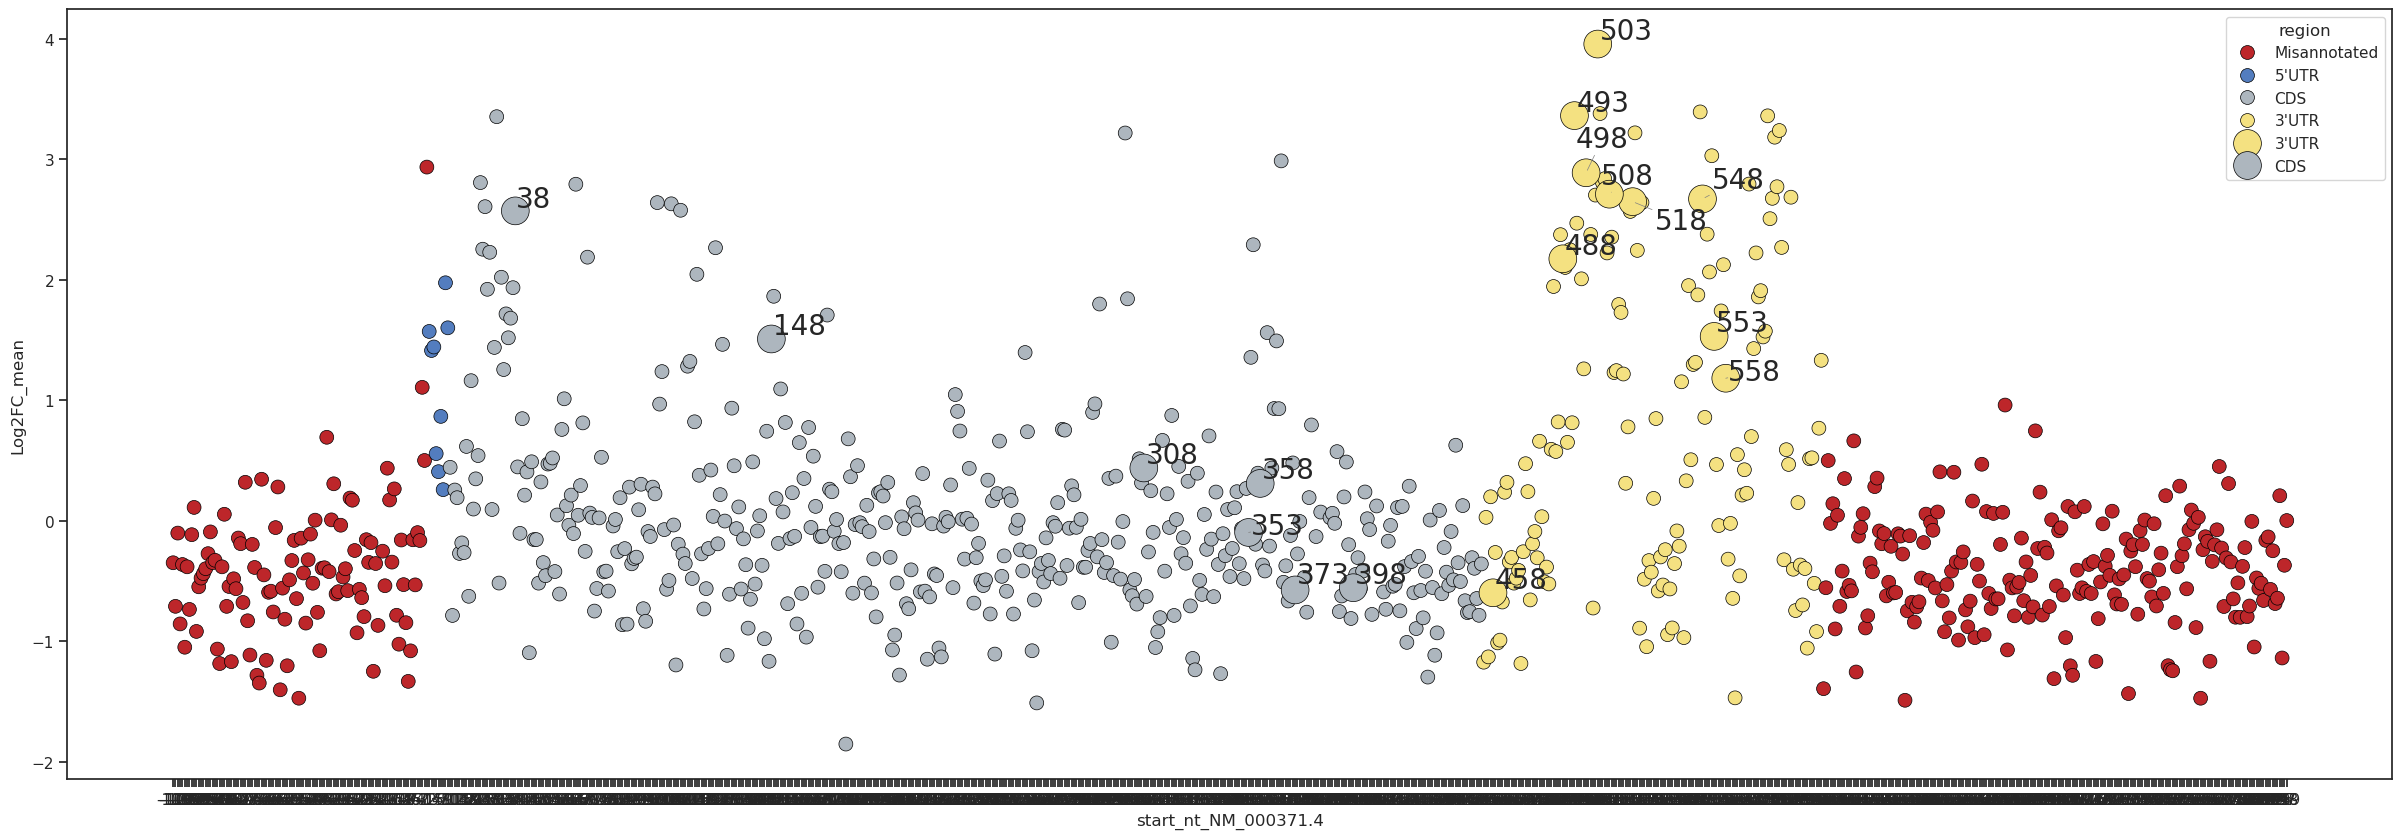

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text



df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv")
df = df[~(df["region"] == "NTC")].astype({'start_nt_NM_000371.3': int})

plt.figure(figsize=(30, 10))

custom_palette = {
    "Misannotated": "#bd262a",
    "5'UTR": "#537dbf",
    "CDS": "#adb6be",
    "3'UTR": "#f4e181",
}

sns.scatterplot(
    data=df, 
    x="start_nt_NM_000371.4", 
    y="Log2FC_mean", 
    hue="region", 
    palette=custom_palette, 
    s = 100, 
    edgecolor="black", 
    linewidth = 0.5
)


validated = [613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258, 568]
df_validated = df[df["start_nt_NM_000371.3"].isin(validated)].sort_values(by=['Log2FC_mean'], ascending=True)
df_validated

sns.scatterplot(
    data=df_validated,
    x="start_nt_NM_000371.4",
    y="Log2FC_mean",
    hue="region",
    palette=custom_palette,
    s=400,
    edgecolor="black",
    linewidth=0.5,
)
texts = []
for index, row in df_validated.iterrows():
    texts.append(
        plt.text(
            row["start_nt_NM_000371.4"],
            row["Log2FC_mean"],
            row["start_nt_NM_000371.4"],  # <-- Your label column
            size=20,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/TTR_shRNAone_1nt_scatter_region.pdf", dpi=300, bbox_inches='tight')

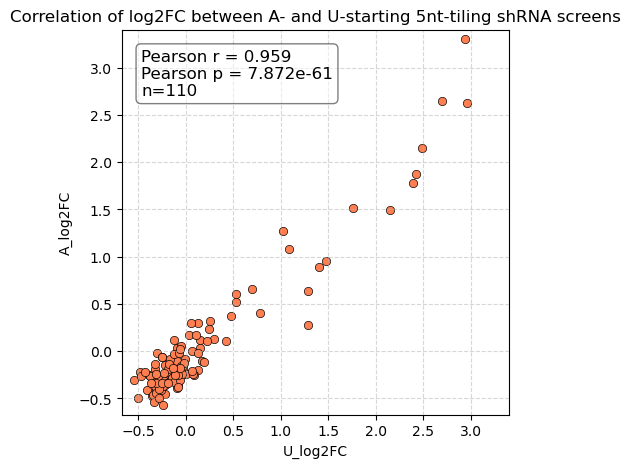

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_5nt.csv")
U_log2FC = df[df["tech_rep"] == "U_starting"]['Log2FC_mean'].tolist()
A_log2FC = df[df["tech_rep"] == "A_starting"]['Log2FC_mean'].tolist()
PearsonR, PearsonP = pearsonr(U_log2FC, A_log2FC)
df = pd.DataFrame({"U_log2FC": U_log2FC, "A_log2FC": A_log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='U_log2FC', y='A_log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlim(min(min(U_log2FC), min(A_log2FC)) - 0.1, max(max(U_log2FC), max(A_log2FC)) + 0.1)
plt.ylim(min(min(U_log2FC), min(A_log2FC)) - 0.1, max(max(U_log2FC), max(A_log2FC)) + 0.1)

plt.title('Correlation of log2FC between A- and U-starting 5nt-tiling shRNA screens')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_TTR_shRNAone_5nt_tech_reps.pdf", bbox_inches='tight')
plt.show()
plt.close()


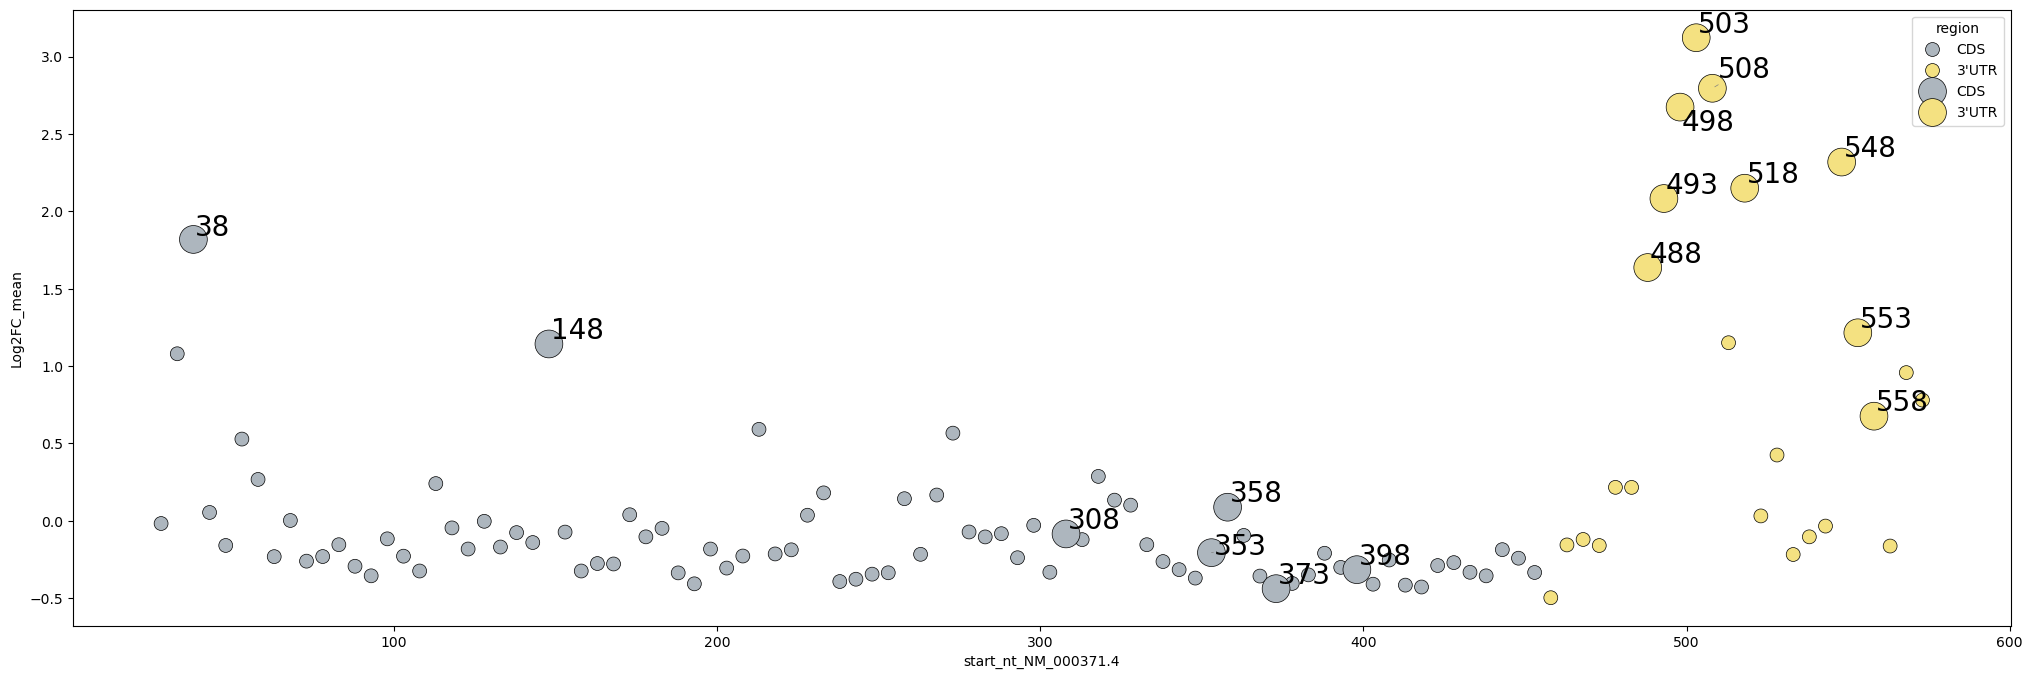

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_5nt.csv")
df = df[~(df["region"] == "NTC")]
df_U = df[df["tech_rep"] == "U_starting"].astype({'start_nt_NM_000371.4': int, 'start_nt_NM_000371.3': int})
df_A = df[df["tech_rep"] == "A_starting"].astype({'start_nt_NM_000371.4': int, 'start_nt_NM_000371.3': int})
mean = [(x + y) / 2 for x,y in zip(df_U["Log2FC_mean"], df_A["Log2FC_mean"])]
start_4 = df_U["start_nt_NM_000371.4"].to_list()
start_3 = df_U["start_nt_NM_000371.3"].to_list()
region = df_U["region"].to_list()
df = pd.DataFrame({"start_nt_NM_000371.4": start_4, "start_nt_NM_000371.3": start_3, "Log2FC_mean": mean, "region": region}).sort_values(by=['start_nt_NM_000371.4'], ascending=True)


plt.figure(figsize=(25, 8))

custom_palette = {
    "Misannotated": "#bd262a",
    "5'UTR": "#537dbf",
    "CDS": "#adb6be",
    "3'UTR": "#f4e181",
}

sns.scatterplot(
    data=df, 
    x="start_nt_NM_000371.4", 
    y="Log2FC_mean", 
    hue="region", 
    palette=custom_palette, 
    s = 100, 
    edgecolor="black", 
    linewidth = 0.5
)

validated = [613, 618, 608, 418, 468, 463, 483, 668, 508, 628, 658, 603, 148, 598, 663, 258]
df_validated = df[df["start_nt_NM_000371.3"].isin(validated)].sort_values(by=['Log2FC_mean'], ascending=True)
df_validated

sns.scatterplot(
    data=df_validated,
    x="start_nt_NM_000371.4",
    y="Log2FC_mean",
    hue="region",
    palette=custom_palette,
    s=400,
    edgecolor="black",
    linewidth=0.5,
)

texts = []
for index, row in df_validated.iterrows():
    texts.append(
        plt.text(
            row["start_nt_NM_000371.4"],
            row["Log2FC_mean"],
            row["start_nt_NM_000371.4"],  # <-- Your label column
            size=20,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/TTR_shRNAone_5nt_scatter_region.pdf", dpi=300, bbox_inches='tight')

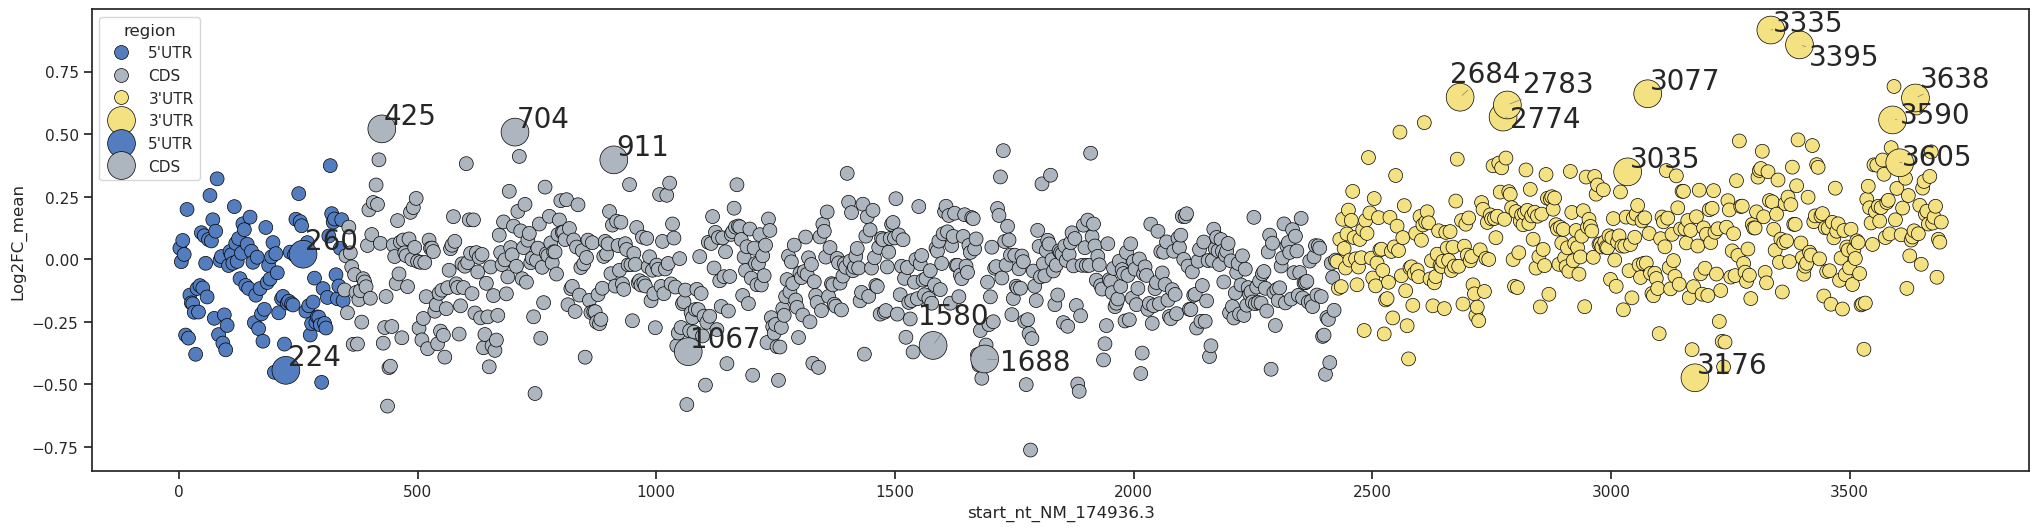

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_PCSK9_shRNAone_3nt.csv")
df = df[~(df["region"] == "NTC")].astype({"start_nt_NM_174936.3": int})

plt.figure(figsize=(25, 6))

custom_palette = {
    "5'UTR": "#537dbf",
    "CDS": "#adb6be",
    "3'UTR": "#f4e181",
}

sns.scatterplot(
    data=df, 
    x="start_nt_NM_174936.3", 
    y="Log2FC_mean", 
    hue="region", 
    palette=custom_palette, 
    s = 100, 
    edgecolor="black", 
    linewidth = 0.5
)

validated = [3335, 3395, 3638, 704, 2684, 3077, 425, 3590, 3035, 2783, 2774, 911, 3176, 260, 1688, 1067, 1580, 224, 3605]
df_validated = df[df["start_nt_NM_174936.3"].isin(validated)].sort_values(by=['Log2FC_mean'], ascending=True)
df_validated

sns.scatterplot(
    data=df_validated,
    x="start_nt_NM_174936.3",
    y="Log2FC_mean",
    hue="region",
    palette=custom_palette,
    s=400,
    edgecolor="black",
    linewidth=0.5,
)

texts = []
for index, row in df_validated.iterrows():
    texts.append(
        plt.text(
            row["start_nt_NM_174936.3"],
            row["Log2FC_mean"],
            row["start_nt_NM_174936.3"],  # <-- Your label column
            size=20,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/PCSK9_shRNAone_3nt_scatter_region.pdf", dpi=300, bbox_inches='tight')

In [ ]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

df_Psp = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_PspCas13b_1nt.csv")[["start_nt_NM_000371.4", "Log2FC_mean"]]
df_Psp= df_Psp[~(df_Psp["start_nt_NM_000371.4"] ==  "NTC")].astype({'start_nt_NM_000371.4': int})
Psp_Log2FC = list(df_Psp[(df_Psp["start_nt_NM_000371.4"] > 0) & (df_Psp["start_nt_NM_000371.4"] < 588)]["Log2FC_mean"])


df_shRNA = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv")
df_shRNA= df_shRNA[~(df_shRNA["start_nt_NM_000371.4"] ==  "NTC")].astype({'start_nt_NM_000371.4': int})
df_shRNA = df_shRNA[(df_shRNA["start_nt_NM_000371.4"] > 0) & (df_shRNA["start_nt_NM_000371.4"] < 600)]
shRNA_Log2FC = df_shRNA[['rep1_Log2FC', 'rep2_Log2FC', 'rep3_Log2FC']].mean(axis=1).tolist()  # Assuming rep1_Log2FC, rep2_Log2FC, and rep3_Log2FC are defined elsewhere



def analyze_offsets(long_list, short_list, max_offset=30):
    results = []
    short_len = len(short_list)
    
    for offset in range(max_offset + 1):
        # Slice the long list starting at the offset, with the length of the short list
        # If the offset goes past the end of the long list, it naturally truncates
        long_slice = long_list[offset : offset + short_len]
        
        # Trim the short list if the long slice runs out of items near the end
        current_short = short_list[:len(long_slice)]
        
        # Create DataFrame with the paired lists
        df = pd.DataFrame({
            'shRNA_Log2FC': long_slice,
            'Psp_Log2FC': current_short
        })
        
        # Drop rows where either value is missing (NaN)
        df_clean = df.dropna()
        
        # Get the number of valid pairs remaining
        valid_pairs = len(df_clean)
        
        # Calculate Spearman correlation if we have enough data points (at least 2)

        corr, p_val = spearmanr(df_clean['shRNA_Log2FC'], df_clean['Psp_Log2FC'])

            
        results.append({
            'Offset': offset,
            'Valid_Pairs': valid_pairs,
            'Spearman_Rho': corr,
            'P_Value': p_val
        })
        
    return pd.DataFrame(results)

# --- 3. Run and View Results ---
results_df = analyze_offsets(shRNA_Log2FC, Psp_Log2FC, max_offset=30)
print(results_df.to_string(index=False))

# for i in range(0, 30):
#     shRNA_Log2FC_ = shRNA_Log2FC[i:]
#     shRNA_Log2FC_ = shRNA_Log2FC_[:min(len(shRNA_Log2FC), len(Psp_Log2FC))]
#     print(len(shRNA_Log2FC_), len(Psp_Log2FC))
#     df_merged = pd.DataFrame({'shRNA_Log2FC': shRNA_Log2FC_, 'Psp_Log2FC': Psp_Log2FC}).dropna()
#     # print(df_merged.isna().sum())
#     res = spearmanr(df_merged['shRNA_Log2FC'], df_merged['Psp_Log2FC'])
#     print(f"Spearman correlation coefficient (offset: {i}): {res.correlation:.3f}, p-value: {res.pvalue:.3e}, n={len(df_merged)}")

[477, 482, 472, 282, 332, 327, 347, 532, 372, 492, 522, 467, 12, 462, 527, 122]


/tmp/ipykernel_140602/1601925936.py:36: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


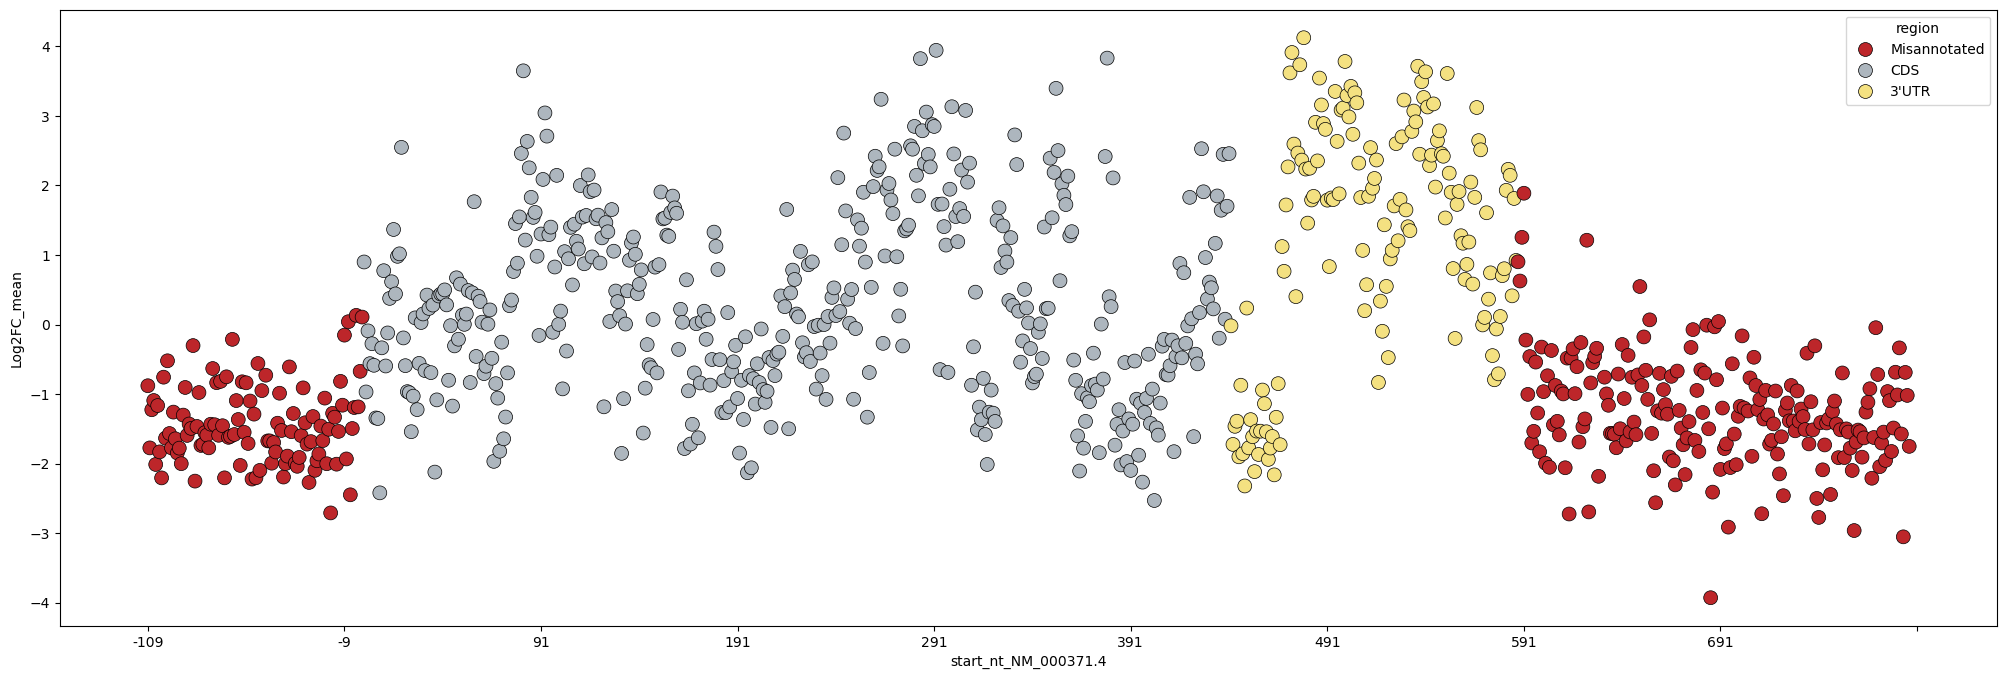

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import numpy as np



df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/Log2FC_TTR_PspCas13b_1nt.csv")
df = df[~(df["region"] == "NTC")].astype({'start_nt_NM_000371.3': int})

plt.figure(figsize=(25, 8))

custom_palette = {
    "Misannotated": "#bd262a",
    "5'UTR": "#537dbf",
    "CDS": "#adb6be",
    "3'UTR": "#f4e181",
}

sns.scatterplot(
    data=df, 
    x="start_nt_NM_000371.4", 
    y="Log2FC_mean", 
    hue="region", 
    palette=custom_palette, 
    s = 100, 
    edgecolor="black", 
    linewidth = 0.5
)

validated = []
df_validated = df[df["start_nt_NM_000371.3"].isin(validated)].sort_values(by=['Log2FC_mean'], ascending=True)
df_validated

sns.scatterplot(
    data=df_validated,
    x="start_nt_NM_000371.4",
    y="Log2FC_mean",
    hue="region",
    palette=custom_palette,
    s=400,
    edgecolor="black",
    linewidth=0.5,
)

texts = []
for index, row in df_validated.iterrows():
    texts.append(
        plt.text(
            row["start_nt_NM_000371.4"],
            row["Log2FC_mean"],
            row["start_nt_NM_000371.4"],  # <-- Your label column
            size=20,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.xticks(np.arange(0, 1000, 100))

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/main_text/TTR_PspCas13b_1nt_scatter_region.pdf", dpi=300, bbox_inches='tight')

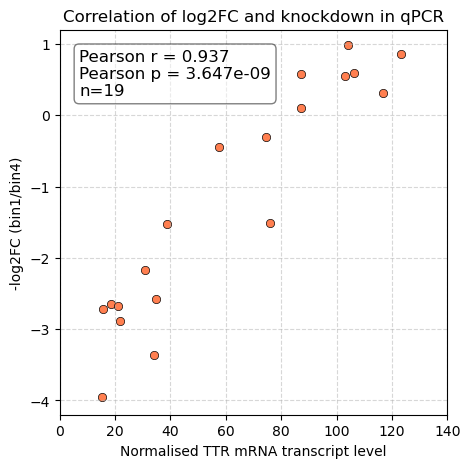

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/TTR_shRNA_qPCR_log2FC.csv")
qPCR = df['qPCR'].tolist()
log2FC = df['log2FC'].tolist()
PearsonR, PearsonP = pearsonr(qPCR, log2FC)
df = pd.DataFrame({"qPCR": qPCR, "log2FC": log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='qPCR', y='log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel("Normalised TTR mRNA transcript level")
plt.ylabel("-log2FC (bin1/bin4)")
plt.xlim(0, 140)
plt.ylim(-4.2, 1.2)

plt.title('Correlation of log2FC and knockdown in qPCR')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_screen_vs_shRNA.pdf", bbox_inches='tight')
plt.show()
plt.close()


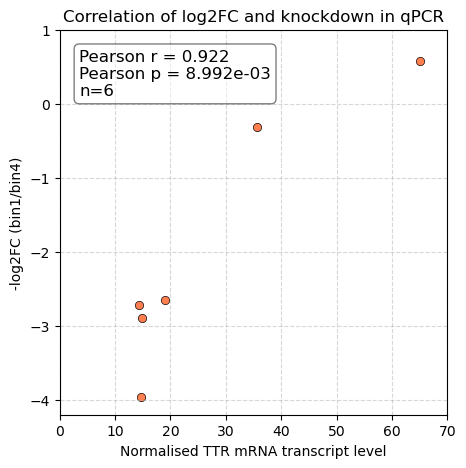

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/TTR_siRNA_qPCR_log2FC.csv")
qPCR = df['qPCR'].tolist()
log2FC = df['log2FC'].tolist()
PearsonR, PearsonP = pearsonr(qPCR, log2FC)
df = pd.DataFrame({"qPCR": qPCR, "log2FC": log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='qPCR', y='log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel("Normalised TTR mRNA transcript level")
plt.ylabel("-log2FC (bin1/bin4)")
plt.xlim(0, 70)
plt.ylim(-4.2, 1)

plt.title('Correlation of log2FC and knockdown in qPCR')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_screen_vs_siRNA.pdf", bbox_inches='tight')
plt.show()
plt.close()


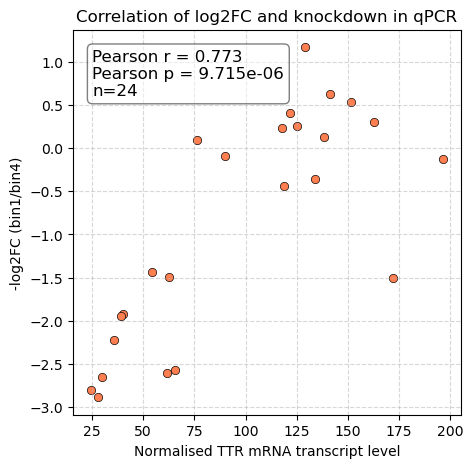

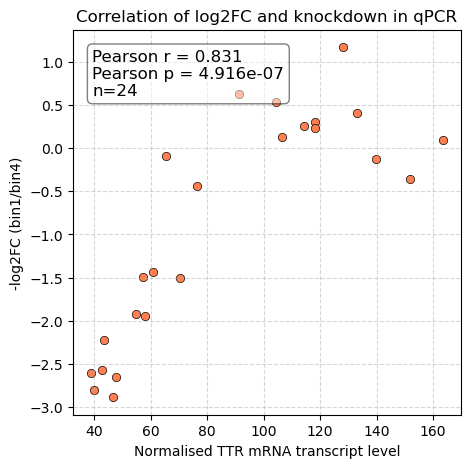

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/log2FC_validated.csv")
qPCR_shRNAone = df['shRNAone'].tolist()
qPCR_shRNAmir = df['shRNAmir'].tolist()
log2FC = df['log2FC'].tolist()
PearsonR, PearsonP = pearsonr(qPCR_shRNAone, log2FC)
df = pd.DataFrame({"qPCR_shRNAone": qPCR_shRNAone, "log2FC": log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='qPCR_shRNAone', y='log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel("Normalised TTR mRNA transcript level")
plt.ylabel("-log2FC (bin1/bin4)")
# plt.xlim(0, 70)
# plt.ylim(-3.2, 1)

plt.title('Correlation of log2FC and knockdown in qPCR')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_screen_vs_shRNAone.pdf", bbox_inches='tight')
plt.show()
plt.close()

df = pd.DataFrame({"qPCR_shRNAmir": qPCR_shRNAmir, "log2FC": log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)
PearsonR, PearsonP = pearsonr(qPCR_shRNAmir, log2FC)
sns.scatterplot(data=df, x='qPCR_shRNAmir', y='log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel("Normalised TTR mRNA transcript level")
plt.ylabel("-log2FC (bin1/bin4)")
# plt.xlim(0, 70)
# plt.ylim(-3.2, 1)

plt.title('Correlation of log2FC and knockdown in qPCR')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_screen_vs_shRNAmir.pdf", bbox_inches='tight')
plt.show()
plt.close()


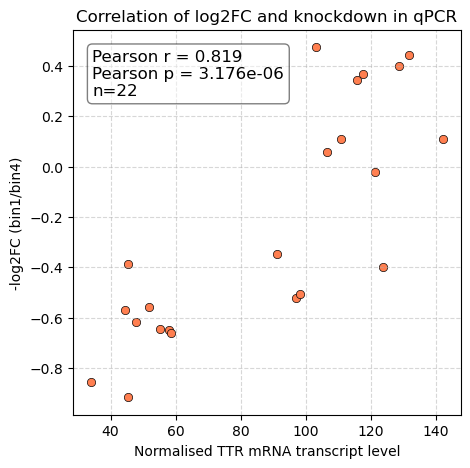

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats

df = pd.read_csv("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_analysis/output/PCSK9_shRNA_qPCR_log2FC.csv")
qPCR = df['qPCR'].tolist()
log2FC = df['log2FC'].tolist()
PearsonR, PearsonP = pearsonr(qPCR, log2FC)
df = pd.DataFrame({"qPCR": qPCR, "log2FC": log2FC})
plt.figure(figsize=(5, 5))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='qPCR', y='log2FC', 
            color= 'coral', edgecolors =  'black')


text_str = f'Pearson r = {PearsonR:.3f}\nPearson p = {PearsonP:.3e}\nn={len(df)}'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel("Normalised TTR mRNA transcript level")
plt.ylabel("-log2FC (bin1/bin4)")
# plt.xlim(0, 140)
# plt.ylim(-4.2, 1.2)

plt.title('Correlation of log2FC and knockdown in qPCR')

plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/correlations_screen_vs_shRNA_PCSK9.pdf", bbox_inches='tight')
plt.show()
plt.close()
